# Stage 7, Part 3: Optimizers, Regularization, and RNNs/LSTMs (Conceptual)

**Goal:** close out the remaining Stage 7 gaps. You'll extend your existing CNN with better optimizers and regularization techniques, seeing their effects directly rather than just reading about them. RNNs/LSTMs get a conceptual-only treatment, since the roadmap deliberately routes you toward attention/Transformers (Stage 8) instead of hands-on RNN implementation.

Reuses your Part 2 setup — same venv, same MNIST DataLoaders, same CNN architecture as your baseline.

## 1. Recap: what plain SGD is missing

Your Part 2 CNN used `optim.SGD(model.parameters(), lr=0.01)` — the simplest possible update rule: `W = W - learning_rate * dW`, applied identically every step, with no memory of previous steps.

Two real limitations this creates, which the sections below directly address:
- Plain SGD can be slow to converge and prone to oscillating back and forth in narrow valleys of the loss landscape (conceptually similar to the instability you fought with in Part 1, just a different cause).
- Plain SGD has no built-in mechanism to prevent overfitting — given enough training, a large enough network will eventually start memorizing training data rather than generalizing.

Re-run your Part 2 setup cells here (imports, DataLoaders, and your `CNN` class) so this notebook is self-contained.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# TODO: paste in your DataLoader setup and CNN class definition from Part 2

# Load MNIST training dataset
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

# Load MNIST test dataset
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)




class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128) # -- after 2 pooling layers, 28x28 has shrunk to 7x7
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        

    def forward(self, x): 
        x = self.relu(self.conv1(x))     #Conv + ReLU
        x = self.pool(x)                 # Pooling #1: 28×28 → 14×14

        x = self.relu(self.conv2(x))     #Conv + ReLU
        x = self.pool(x)                 # Pooling #2: 14×14 → 7×7

        x = x.view(x.size(0), -1)        #Flatten
        x = self.relu(self.fc1(x))       #FC layers
        x = self.fc2(x)

        return x


## 2. Optimizer variants

### Momentum

Plain SGD only looks at the CURRENT gradient. Momentum adds a "velocity" term that accumulates a running average of past gradients — conceptually like a ball rolling downhill that builds up speed in a consistent direction, and doesn't instantly change direction just because one step's gradient was noisy. This directly counters the oscillation problem from Section 1.

**Syntax note:** `optim.SGD(model.parameters(), lr=0.01, momentum=0.9)` — the `momentum` argument (commonly 0.9) controls how much of the previous step's direction carries over into the current one.

### Adam

Adam (Adaptive Moment Estimation) goes further — it keeps a running average of both the gradient itself (like momentum) AND the squared gradient, using the second to automatically adapt the effective learning rate for EACH parameter individually. Parameters that have been getting large, consistent gradients get smaller effective steps; parameters with small or noisy gradients get relatively larger ones. This is why Adam is the most common default optimizer in modern deep learning — it typically converges faster with less manual learning-rate tuning than plain SGD.

**Syntax note:** `optim.Adam(model.parameters(), lr=0.001)` — note Adam's typical learning rate (0.001) is usually smaller than SGD's, since Adam's adaptive scaling already does some of the work a larger SGD learning rate would otherwise need to.

Train three identical CNNs (same architecture, same number of epochs), varying only the optimizer: plain SGD, SGD+momentum, Adam. Plot all three loss curves on the same chart for direct comparison.

In [ ]:
def train_and_get_loss(model, optimizer, criterion, train_loader, n_epochs=3):

    loss_history = []
    for epoch in range(n_epochs):
        for images, labels in train_loader:

            # 1. Clear gradients from the previous iteration
            optimizer.zero_grad()

            # 2. Forward pass:
            #    Feed images through the neural network
            #    outputs = the model's predictions (10 scores per image)
            outputs = model(images)

            # 3. Calculate how wrong the predictions are
            loss = criterion(outputs, labels)

            # 4. Save the numerical loss for plotting later
            loss_history.append(loss.item())

            # 5. Backpropagation:
            #    Calculate the gradient of the loss with respect to
            #    every learnable parameter in the model
            loss.backward()

            # 6. Update the weights using those gradients
            optimizer.step()
    return loss_history

# TODO: instantiate 3 fresh CNN() models, one optimizer each (SGD, SGD+momentum, Adam), train each with the function above


model_sgd = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_sgd.parameters(), lr=0.01)
loss_history_sgd = train_and_get_loss(model_sgd,optimizer, criterion,train_loader,n_epochs=3)


model_sgd_momentum = CNN()
optimizer = optim.SGD(model_sgd_momentum.parameters(), lr=0.01, momentum=0.9)
loss_history_sgd_momentum = train_and_get_loss(model_sgd_momentum,optimizer, criterion,train_loader,n_epochs=3)




model_adam = CNN()
optimizer = optim.Adam(model_adam.parameters(), lr=0.001)
loss_history_adam= train_and_get_loss(model_adam,optimizer, criterion,train_loader,n_epochs=3)






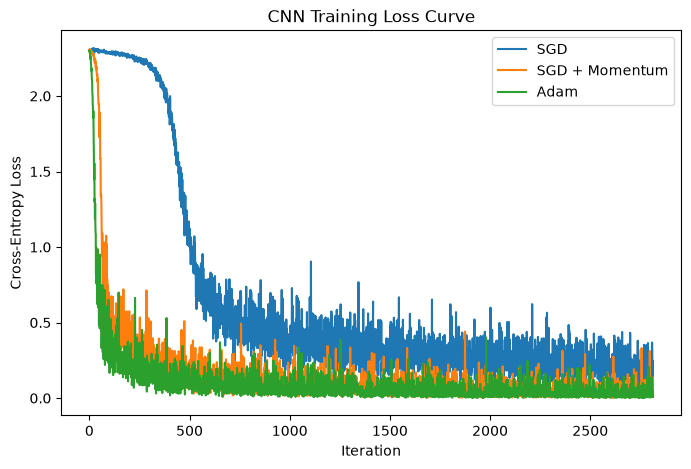

In [6]:
# TODO: plot all 3 loss histories on one chart, labeled, for direct comparison

plt.figure(figsize=(8, 5))

plt.plot(loss_history_sgd, label="SGD")
plt.plot(loss_history_sgd_momentum, label="SGD + Momentum")
plt.plot(loss_history_adam, label="Adam")

plt.xlabel("Iteration")
plt.ylabel("Cross-Entropy Loss")
plt.title("CNN Training Loss Curve")
plt.legend()

plt.show()

Guiding question: which optimizer reached a low loss fastest (fewest iterations)? Does this match what the conceptual explanation above predicted?

SGD + Momentum and Adam performed more optimal than regular SGD. It sems that Adam required less iterations to reach a low loss faster than the other two loss curves.


## 3. Regularization

### L2 weight decay

Adds a penalty to the loss proportional to the size of the weights themselves, discouraging any single weight from growing very large. Large weights are often a sign of the model fitting noise/specific training examples rather than genuine patterns.

**Syntax note:** `optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)` — the `weight_decay` argument adds this penalty automatically; no change to your training loop needed.

### Dropout

During training, randomly "turns off" (zeroes out) a fraction of neurons on each forward pass. This prevents the network from becoming overly reliant on any single neuron, forcing it to learn more redundant, robust representations. Dropout is automatically disabled during evaluation (`model.eval()` handles this).

**Syntax note:** add `self.dropout = nn.Dropout(p=0.5)` in `__init__`, and call `x = self.dropout(x)` in `forward` — typically right before the final fully-connected layer. `p=0.5` means each neuron has a 50% chance of being zeroed out on any given forward pass during training.

### Batch normalization

Normalizes the activations within each mini-batch to have consistent mean/variance before passing to the next layer, which tends to stabilize and speed up training — conceptually related to why you scaled input features back in Stage 3/4, but applied to intermediate activations throughout the network, not just the raw input.

**Syntax note:** `self.bn1 = nn.BatchNorm2d(16)` after a conv layer with 16 output channels, called as `x = self.bn1(self.conv1(x))` before the activation function.

Build a new CNN class adding dropout (and optionally batch norm) to your Part 2 architecture, train it with Adam + weight_decay, and compare its final test accuracy against your original unregularized CNN from Part 2.

In [ ]:
class RegularizedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: same conv/pool structure as your Part 2 CNN, plus nn.Dropout and optionally nn.BatchNorm2d
        self.dropout = nn.Dropout(p=0.5)
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128) # -- after 2 pooling layers, 28x28 has shrunk to 7x7
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
       

    def forward(self, x): 
        x = self.relu(self.conv1(x))     #Conv + ReLU
        x = self.pool(x)                 # Pooling #1: 28×28 → 14×14

        x = self.relu(self.conv2(x))     #Conv + ReLU
        x = self.pool(x)                 # Pooling #2: 14×14 → 7×7

        x = x.view(x.size(0), -1)        #Flatten
        x = self.relu(self.fc1(x))       #FC layers
        x = self.dropout(x) 
        x = self.fc2(x)
        x

        return x



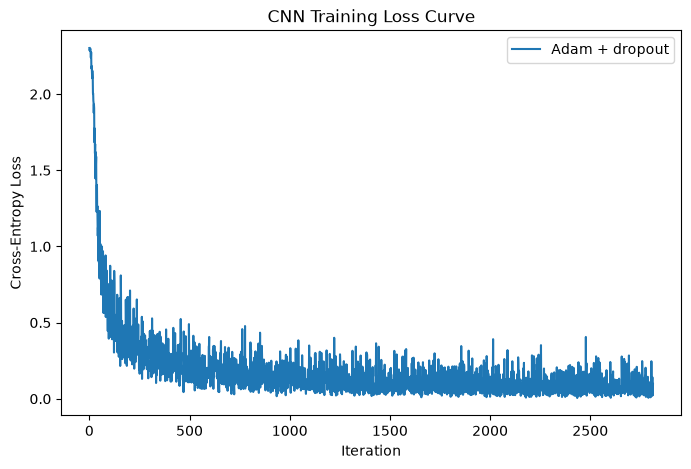

In [10]:
# TODO: train RegularizedCNN with Adam(lr=0.001, weight_decay=1e-4), evaluate test accuracy,
# compare against your Part 2 CNN's 96.8% baseline




model = RegularizedCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-4)
loss_history= train_and_get_loss(model,optimizer, criterion,train_loader,n_epochs=3)



plt.figure(figsize=(8, 5))

plt.plot(loss_history, label="Adam + dropout")

plt.xlabel("Iteration")
plt.ylabel("Cross-Entropy Loss")
plt.title("CNN Training Loss Curve")
plt.legend()

plt.show()

In [11]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

rnnn_accuracy = correct / total
print("CNN Accuracy:", rnnn_accuracy)

CNN Accuracy: 0.9882


Guiding question: MNIST is a fairly easy, low-overfitting-risk dataset given how much training data exists relative to the problem's difficulty. Given that, would you expect regularization to help accuracy dramatically here, or might its benefits show up more on a harder/smaller dataset? Is a small (or even negative) change in test accuracy from adding regularization actually a bad sign?

Since the data has low risk to overfitting I would expect that regularization does not help dramatically with accuracy here. However, with reguarlization and adam, it does seem that the accuracy shot up from 96% to 98% which is worth mentioning.

## 4. RNNs and LSTMs (conceptual only — no implementation)

**The problem RNNs were built to solve:** everything so far (feedforward nets, CNNs) processes fixed-size, independent inputs — one image in, one prediction out, with no sense of order or sequence. Language, time-series, and any sequential data need something different: a model that processes one element at a time while maintaining some memory of what came before.

**How an RNN works, at a high level:** it processes a sequence one step at a time, maintaining a "hidden state" that gets updated at each step and carries information forward to the next. Conceptually, the hidden state is the network's working memory of everything it's seen in the sequence so far.

**The core problem: vanishing gradients.** When backpropagating through a long sequence, gradients have to flow backward through every single time step — and just like your Part 1 debugging showed how repeated multiplication can shrink or blow up values, gradients flowing through many RNN time steps tend to shrink toward zero (or occasionally explode). This means RNNs struggle to learn long-range dependencies — information from early in a long sequence effectively gets forgotten by the time the network reaches the end.

**LSTMs (Long Short-Term Memory) were designed specifically to fix this** — they add a separate "cell state" and learned gates (forget gate, input gate, output gate) that explicitly control what information gets kept, discarded, or passed through at each step, giving the network a more direct path for gradients to flow through long sequences without vanishing as badly.

**Why this roadmap skips hands-on RNN/LSTM implementation:** they were the standard approach for sequential data for years, but attention-based Transformers (Stage 8) have now largely replaced them for most modern NLP work — attention processes an entire sequence at once rather than one step at a time, sidestepping the vanishing gradient problem entirely by giving every position direct access to every other position, regardless of distance. Understanding *why* RNNs struggled is what makes attention's design make sense — that's the actual reason this section exists, as a conceptual bridge into Stage 8.

## Wrap-up

Write a short summary:
- Which optimizer would you default to for a new project going forward, and why?
- Did regularization help, hurt, or barely change your CNN's accuracy on MNIST? Was that the result you expected given the guiding question in Section 3?
- In your own words, why does the vanishing gradient problem make long sequences hard for RNNs, and how does that motivate attention's very different approach (even without having implemented either yet)?

Going forward it seems that Adam is the default optimizer because of its natural ability to converge reliably compared to the slow to converge SGD. In this scenario reguarlization helped with our CNN's accuracy by about 2%, I would find it more useful on a dataset that is more at risk to overfitting than a simple one like the MNIST.


RNN'S were built for one image in and a prediction our but with no sense of order or sequence. The issue is that when backpropagating through a long sequence, gradients have to flow backward through every single time step, which means that RNN's struggle to learn long range dependencies so info from early in a long sequence effectively gets forgotten by the time the network reaches the end.